# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [3]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the extended Kalman filter
The next notebook cells implement the initialization and iteration functions for the EKF.

In [4]:
% EKF initialization function, called once at the beginning of the simulation
function ekfData = initEKF(xhat0,SigmaX0,priorU,model)
  ekfData.xhat   = xhat0;        % Initial state description  
  ekfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  ekfData.SigmaV = model.SigmaV; % Sensor-noise covariance 
  ekfData.SigmaW = model.SigmaW; % Process-noise covariance
  ekfData.Sw     = model.Sw;     % Cts-time process-noise covariance
  ekfData.priorU = priorU;       % Previous value of input force
  ekfData.model  = model;        % Store model data structure too
  ekfData.Qbump  = 5;            % In case SigmaX collapses
end

In [5]:
% EKF iteration function, called once every measurement interval
function [xhat,bounds,ekfData] = iterEKF(uk,zk,dT,ekfData)
  model = ekfData.model;
  
  % Get data stored in ekfData structure
  priorU = ekfData.priorU;
  SigmaX = ekfData.SigmaX;
  SigmaV = ekfData.SigmaV;
  SigmaW = ekfData.SigmaW;
  Sw     = ekfData.Sw;
  xhat   = ekfData.xhat;
  
  % EKF Step 0: Compute Ahat[k-1], Bhat[k-1]
  Ahat = [1 dT; -model.k1*dT/model.m-3*model.k2*dT*xhat(1)^2/model.m ...
          1-model.b*dT/model.m];
  Bhat = [0; dT/model.m];
  
  % Step 1a: State estimate time update
  xhat = [1 dT; -model.k1*dT/model.m 1-model.b*dT/model.m]*xhat + ...
         [0; -model.k2*dT*xhat(1)^3/model.m] + ...
         [0; dT/model.m]*priorU;
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  SigmaX = Ahat*SigmaX*Ahat' + Bhat*(Sw/dT)*Bhat'; % default method
  % SigmaX = Ahat*SigmaX*Ahat' + SigmaW;           % alternate method
  
  % Step 1c: Output estimate
  zhat = atan(xhat(1)/model.d);
  
  % Step 2a: Estimator gain matrix
  Chat = [model.d/(model.d^2 + xhat(1)^2) 0]; Dhat = 1;
  SigmaZ = Chat*SigmaX*Chat' + Dhat*SigmaV*Dhat';
  L = SigmaX*Chat'/SigmaZ;
  
  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  xhat = xhat + L*r;
  
  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  if r^2 > 16*SigmaZ % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaX = SigmaX*ekfData.Qbump;
  end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ekfData.priorU = uk;
  ekfData.SigmaX = SigmaX;
  ekfData.xhat = xhat;
  bounds = 3*sqrt(diag(SigmaX));
end

### Implementing the extended Kalman filter
The next notebook cells implement the main code of the extended Kalman filter.

In [6]:
% Determine number of states and timesteps
[nx,nt] = size(x); 

In [7]:
% Reserve storage for results
xhatstore  = zeros(nx,nt);
boundstore = zeros(nx,nt);

% Covariance values
SigmaX0 = 0.1*eye(nx,nx); % uncertainty of initial state
xhat0   = zeros(nx,1);

% Create ekfData structure and initialize variables 
ekfData = initEKF(xhat0,SigmaX0,u(1),model);

% Now, enter loop for remainder of time, where we update the EKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Compute estimate of present state vector and its bounds
  [xhatstore(:,k),boundstore(:,k),ekfData] = iterEKF(uk,zk,dT,ekfData);
end

### Plot simulation outputs from the extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

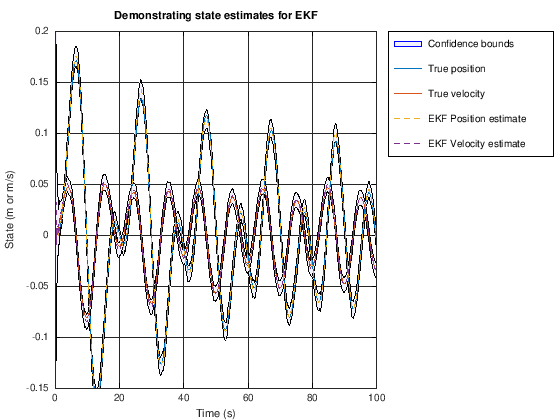

In [8]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x',t,xhatstore','--'); ylim([-0.15 0.2]);
legend([h2;h1a],{'True position','True velocity','EKF Position estimate',...
  'EKF Velocity estimate','Confidence bounds'},'Location','BestOutside'); 
title('Demonstrating state estimates for EKF'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

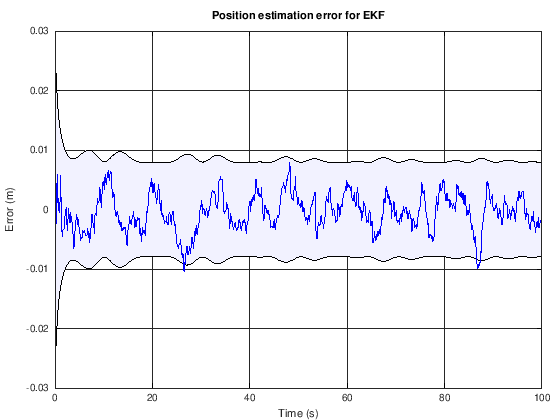

In [9]:
ekfErr = x - xhatstore;
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(1,:),'b');
title('Position estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

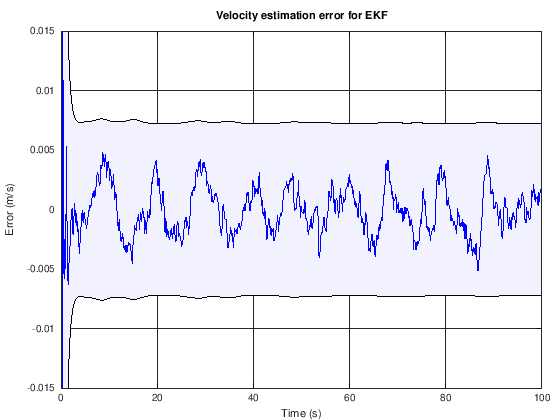

In [10]:
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(2,:),'b'); ylim([-0.015 0.015]);
title('Velocity estimation error for EKF'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

In [11]:
% Compute and output some statistics
fprintf('RMS state estimation error = %g\n',rms(ekfErr(:)));
ind = find(abs(ekfErr(:))>boundstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(:))*100);

RMS state estimation error = 0.0027576
Time error outside bounds = 0.44955%


For interest, we compare the SigmaW computed using the "little trick" of Lesson 1.3.7 with Bhat&times;(Sw/dT)&times;Bhat'. Since dT is small in this example, these matrices are very similar! This explains why the two alternate implementations of Step 1b produce similar results.

In [12]:
Bhat = [0; dT/model.m];
ekfData.SigmaW
Bhat*(ekfData.Sw/dT)*Bhat'

ans =

   1.3291e-09   1.9915e-08
   1.9915e-08   3.9830e-07

ans =

   0.0000e+00   0.0000e+00
   0.0000e+00   4.0000e-07

